### Earthquake Analysis Project


This project analyzes real-time earthquake data pulled from the USGS GeoJSON API, covering:
1. Trend analysis of the data.
2. Regression to predict magnitude based on the location and depth of an earthquake.
3. Clustering to identify earthquake-prone locations.

In [ ]:
import requests
import csv
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor

!pip install Basemap
from mpl_toolkits.basemap import Basemap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 1.8 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.1.6
    Uninstalling pyshp-3.1.6:
      Successfully uninstalled pyshp-3.1.6
  Attempting uninstall: packaging
    Found existing installation: packaging 26.3
    Uninstalling packaging-26.3:
      Successfully uninstalled packaging-26.3


#### Part 1: Prepare the data

Let's pull earthquake data from the past 30 days from the USGS GeoJSON feed and converted into a CSV file.

In [ ]:
url = "https://earthquake.usgs.gov/earthquakes/feed/v1.0/summary/all_month.geojson"

response = requests.get(url)
data = response.json()

features = data['features']

csv_file_path = 'earthquake_data.csv'

with open(csv_file_path, mode='w', newline='') as file:
    writer = csv.writer(file)
    writer.writerow(['time', 'latitude', 'longitude', 'magnitude', 'depth', 'place'])

    for feature in features:
        properties = feature['properties']
        geometry = feature['geometry']
        time = datetime.utcfromtimestamp(properties['time'] / 1000).strftime('%Y-%m-%d')
        longitude, latitude, depth = geometry['coordinates']
        magnitude = properties['mag']
        place = properties['place']

        writer.writerow([time, latitude, longitude, magnitude, depth, place])

/tmp/ipykernel_1265/1648326373.py:17: DeprecationWarning: datetime.datetime.utcfromtimestamp() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.fromtimestamp(timestamp, datetime.UTC).
  time = datetime.utcfromtimestamp(properties['time'] / 1000).strftime('%Y-%m-%d')


The CSV is loaded into a pandas DataFrame for analysis.

In [ ]:
import pandas as pd

csv_file_path = 'earthquake_data.csv'
data = pd.read_csv(csv_file_path)
data.head(5)

,time,latitude,longitude,magnitude,depth,place
0,2026-09-27,38.822834,-122.761833,1.36,1.66,"3 km W of Cobb, CA"
1,2026-09-27,38.793335,-122.807503,1.12,2.98,"5 km WNW of The Geysers, CA"
2,2026-09-27,38.793335,-122.807167,1.17,3.36,"5 km WNW of The Geysers, CA"
3,2026-09-27,38.790833,-122.807999,2.15,3.00,"5 km WNW of The Geysers, CA"
4,2026-09-27,38.794334,-122.760834,0.74,1.19,"2 km NNW of The Geysers, CA"


#### Part 2: Analyze trends in the data

Before applying machine learning, let's explore trends in the data using matplotlib, starting with a time series plot of earthquake frequency over the past 30 days.

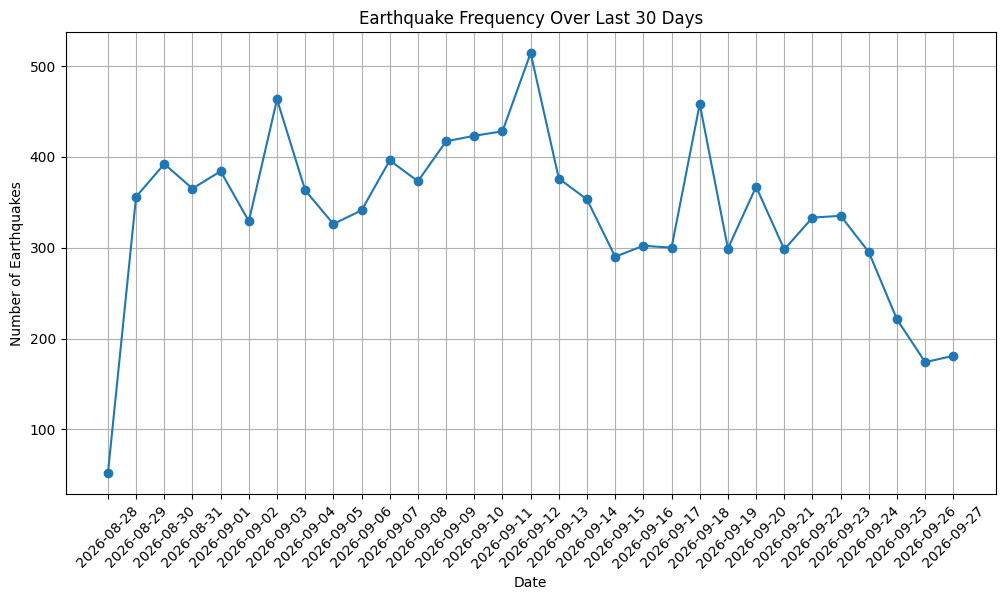

In [ ]:
import matplotlib.pyplot as plt

datedata = data['time'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(datedata.index, datedata.values, marker='o', linestyle='-')
plt.title('Earthquake Frequency Over Last 30 Days')
plt.xlabel('Date')
plt.ylabel('Number of Earthquakes')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

The data shows highlights a surge in earthquake frequency around early June.

Next, let's generate a histogram of earthquake magnitude frequency with a boxplot of magnitude by day.

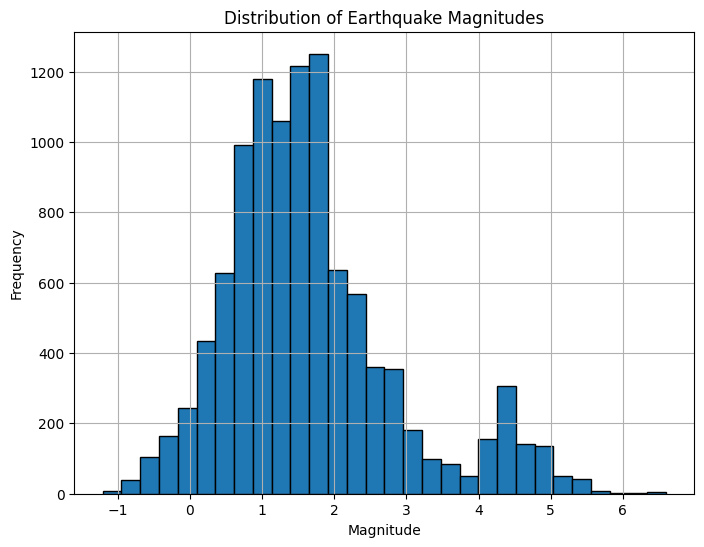

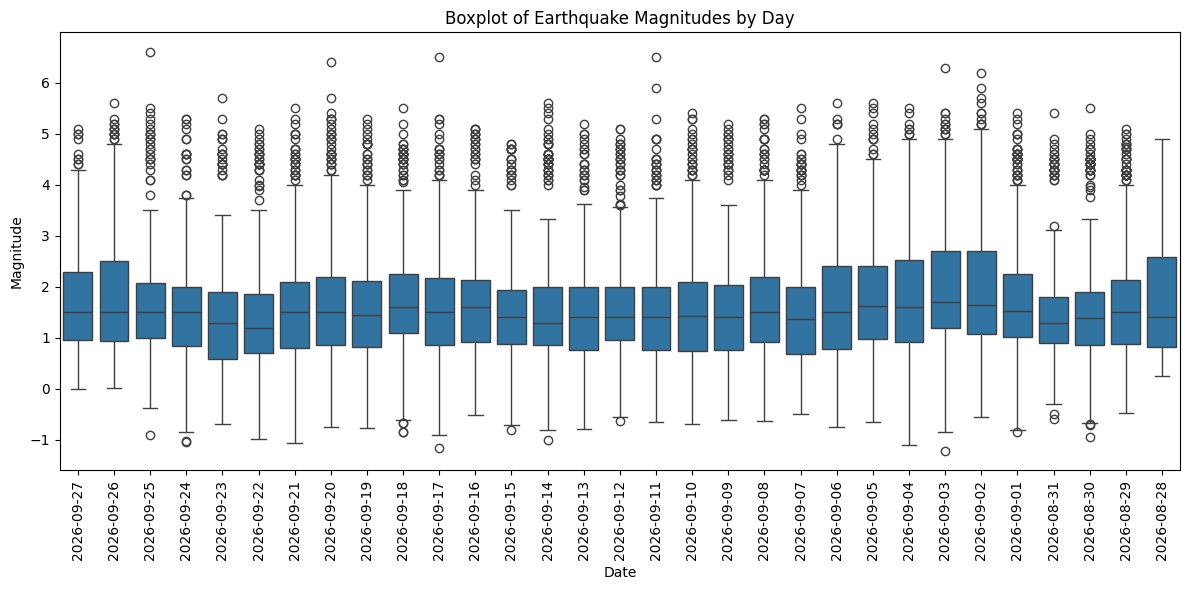

In [ ]:
plt.figure(figsize=(8, 6))
plt.hist(data['magnitude'], bins=30, edgecolor='black')
plt.xlabel('Magnitude')
plt.ylabel('Frequency')
plt.title('Distribution of Earthquake Magnitudes')
plt.grid(True)
plt.show()
print()

plt.figure(figsize=(12, 6))
sns.boxplot(x='time', y='magnitude', data=data)
plt.xticks(rotation=90)
plt.title('Boxplot of Earthquake Magnitudes by Day')
plt.xlabel('Date')
plt.ylabel('Magnitude')
plt.tight_layout()
plt.show()

The distribution shows most earthquakes fall between magnitude 1 and 2.

To complete the trend analysis, let's generate a correlation heatmap and pairplot across earthquake features.

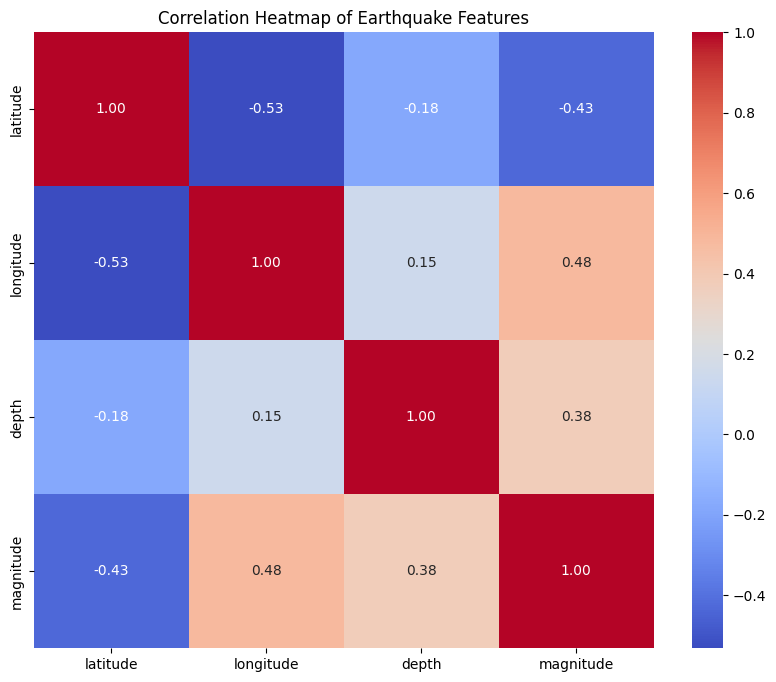


Pair Plot of Earthquake Features


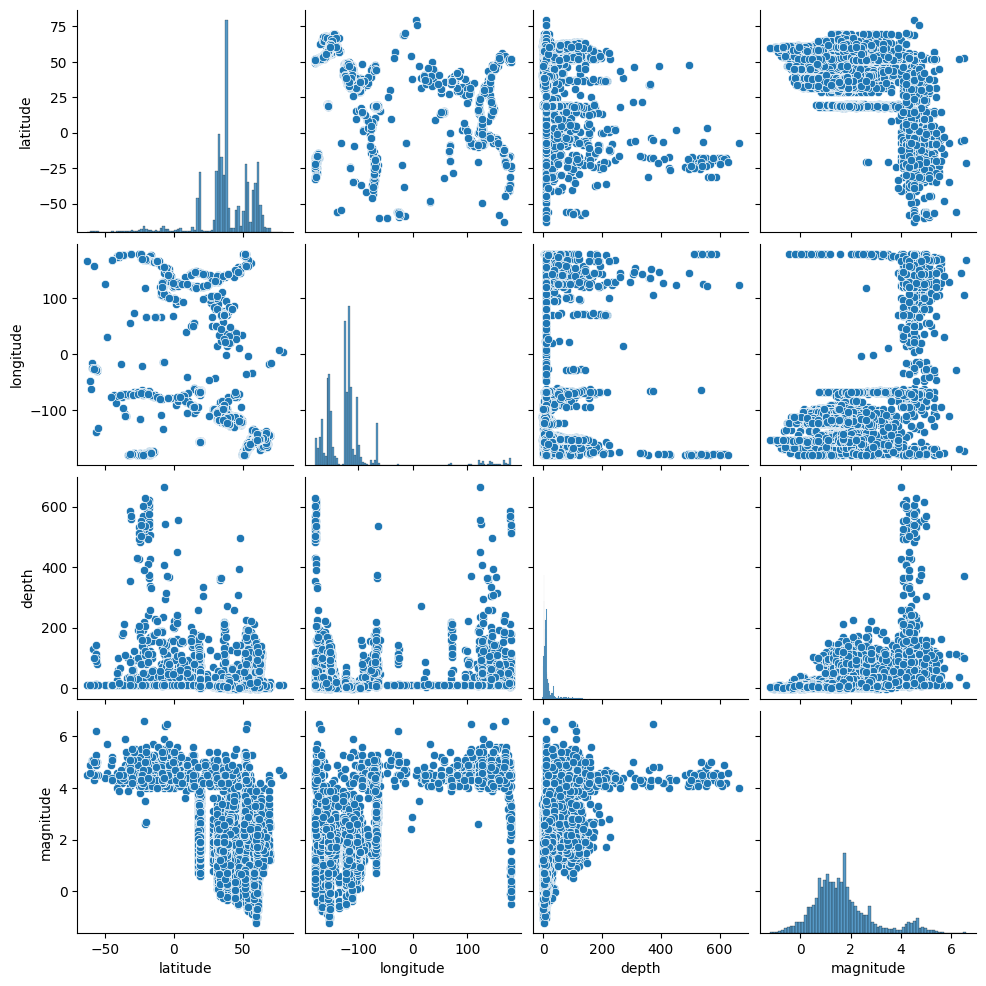

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(data[['latitude', 'longitude', 'depth', 'magnitude']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Earthquake Features')
plt.show()
print()

print('Pair Plot of Earthquake Features')
sns.pairplot(data[['latitude', 'longitude', 'depth', 'magnitude']])

Magnitude correlates most strongly and positively with longitude (0.48), and most strongly and negatively with latitude (-0.43), among the tested features.

The next section builds a model to predict magnitude from these features.

#### Part 3: Machine Learning (Regression)

This section builds regression models to predict earthquake magnitude from latitude, longitude, and depth, starting with extracting the relevant features and creating train/test splits.

In [ ]:
data = data.dropna(subset=['latitude', 'longitude', 'depth', 'magnitude'])

features = data[['latitude', 'longitude', 'depth']]
target = data['magnitude']

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=0)

The model is fit, and RMSE and R^2 are calculated to evaluate performance.

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mean = np.mean(target)

print(f"Root Mean Squared Error: {rmse} or {round(rmse/mean*100)} percent error")
print(f"R-squared: {r2}")


Root Mean Squared Error: 0.9662715983222455 or 58 percent error
R-squared: 0.37186323778956165


The scores indicate linear regression does not predict magnitude well. Let's visualize this with a scatter plot comparing predicted vs. actual magnitude.

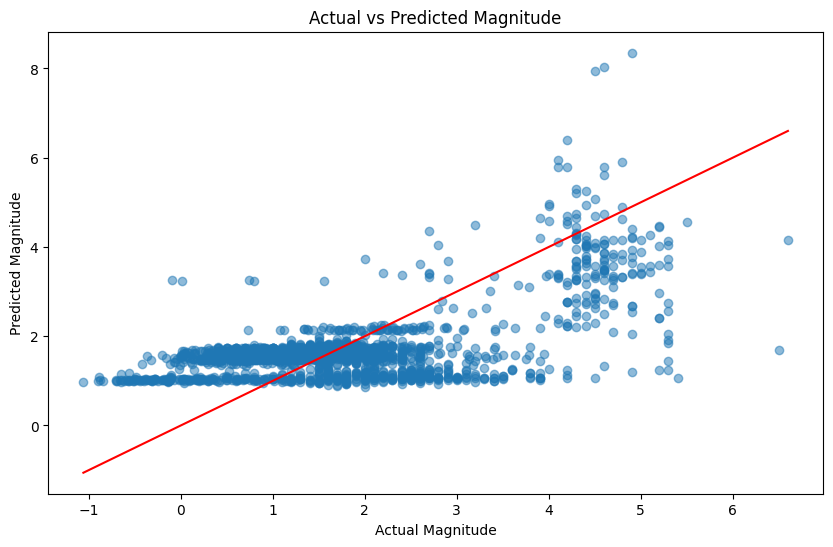

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Actual vs Predicted Magnitude')
plt.show()

Given the high error, let's test a DecisionTreeRegressor next as a non-linear alternative.

Root Mean Squared Error: 0.6437237512847461 or 39 percent error
R-squared: 0.7212243420184851


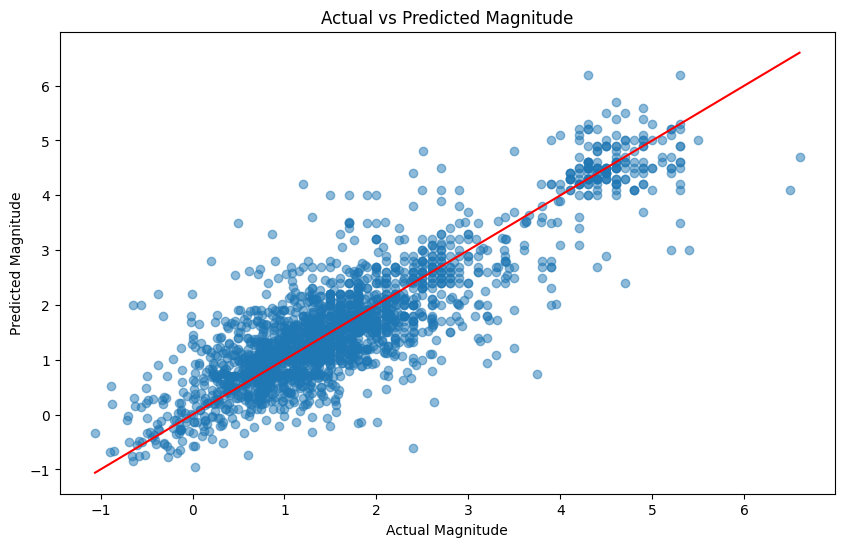

In [ ]:
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mean = np.mean(target)

print(f"Root Mean Squared Error: {rmse} or {round(rmse/mean*100)} percent error")
print(f"R-squared: {r2}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Actual vs Predicted Magnitude')
plt.show()


Comparing both models' metrics and plots, DecisionTreeRegressor outperforms simple LinearRegression at predicting magnitude.

#### Part 4: Machine Learning (Clustering)

This section clusters earthquakes by location to identify earthquake-prone regions, using KMeans. The elbow method is used first to determine an appropriate number of clusters.

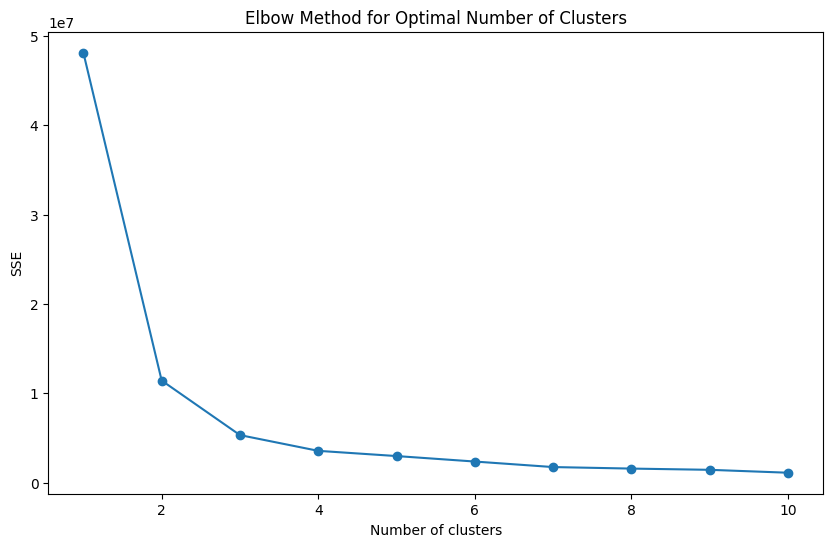

In [ ]:
features = data[['latitude', 'longitude']]

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init = 'auto', random_state=0)
    kmeans.fit(features)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

Based on the elbow plot, 4 clusters is selected as optimal. The model is fit with 4 clusters and visualized with a scatter plot.

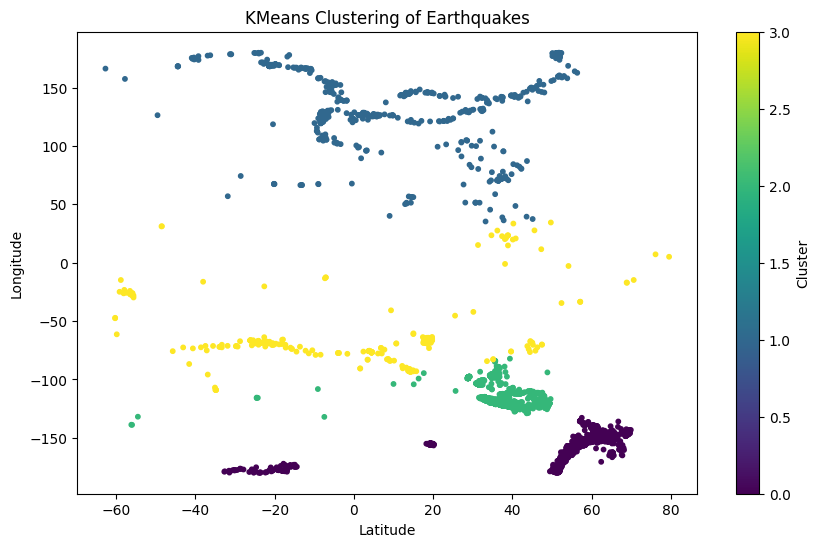

In [ ]:
optimal_clusters = 4
kmeans = KMeans(n_clusters=optimal_clusters, n_init = 'auto', random_state=0)
data['cluster'] = kmeans.fit_predict(features)

plt.figure(figsize=(10, 6))
plt.scatter(data['latitude'], data['longitude'], c=data['cluster'], cmap='viridis', marker='o', s=10)
plt.xlabel('Latitude')
plt.ylabel('Longitude')
plt.title('KMeans Clustering of Earthquakes')
plt.colorbar(label='Cluster')
plt.show()

The clusters align with well-known seismically active regions: western North America and Alaska (roughly -180 to -70 longitude), and the western Pacific (roughly 100 to 180 longitude), which are both segments of the Pacific "Ring of Fire."

#### Part 5: Conclusion

This analysis explored the USGS earthquake GeoJSON feed and found:
1. Dates in the past month with unusually high earthquake frequency.
2. The distribution of earthquake magnitudes.
3. Regression models' ability to predict magnitude from location and depth.
4. Geographic regions with high earthquake density.

#### Part 6: Appendix

This appendix explores two additional models beyond the core analysis for extra insight, starting with RandomForestRegressor.

Root Mean Squared Error: 0.4953663781463646 or 30 percent error
R-squared: 0.8349145356535208


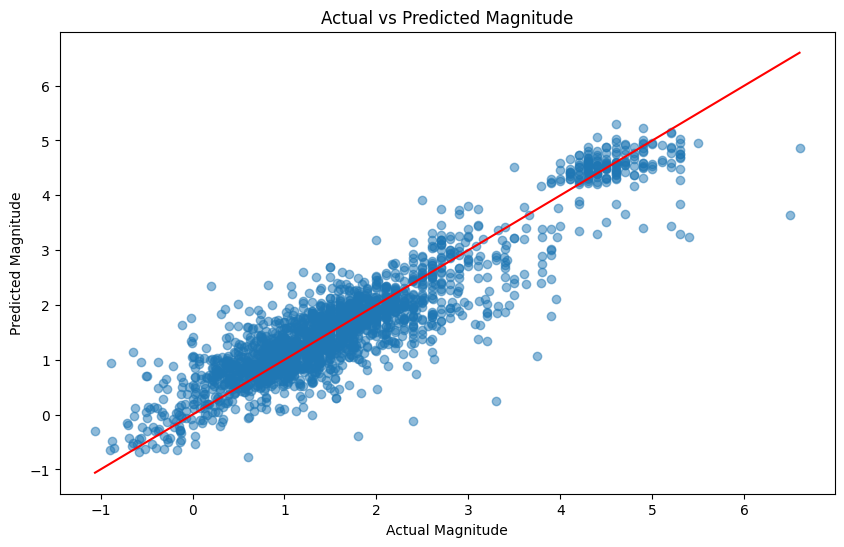

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mean = np.mean(target)

print(f"Root Mean Squared Error: {rmse} or {round(rmse/mean*100)} percent error")
print(f"R-squared: {r2}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], 'r')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Actual vs Predicted Magnitude')
plt.show()


RandomForestRegressor achieves the lowest error and highest R^2 score, outperforming both DecisionTreeRegressor and LinearRegression.

To better visualize the geographic clustering results, let's use Basemap to overlay the KMeans clusters onto an actual world map.

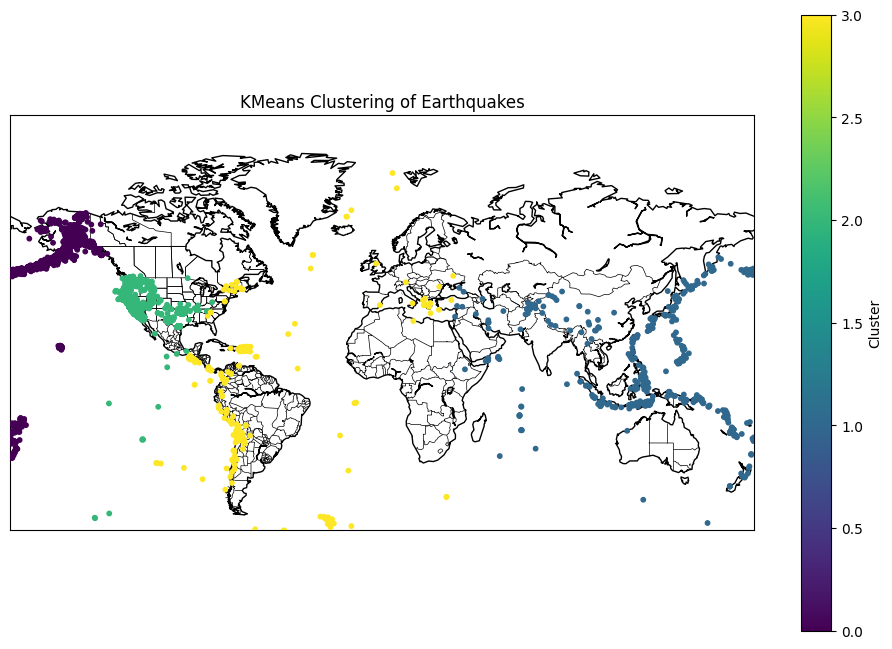

In [ ]:
plt.figure(figsize=(12, 8))

m = Basemap(projection='mill', llcrnrlat=-60, urcrnrlat=90, llcrnrlon=-180, urcrnrlon=180, resolution='c')

m.drawcoastlines()
m.drawcountries()
m.drawstates()

x, y = m(data['longitude'].values, data['latitude'].values)

m.scatter(x, y, c=data['cluster'], cmap='viridis', marker='o', s=10, zorder=5)

plt.title('KMeans Clustering of Earthquakes')
plt.colorbar(label='Cluster')
plt.show()